# Validation of Multi-Path approach via Quantum Teleportation Protocol

This notebook validates multi-path dynamic simulation by matching sampled final states against analytically known branch states, then comparing empirical branch frequencies to analytical targets.

Experiments included:
- Teleportation (4 branch states, uniform target).
- Teleportation with Final Bob Measurement (8 branch states)


In [1]:
from pathlib import Path
import sys
from itertools import product
import numpy as np
import matplotlib.pyplot as plt
import matplotlib
from matplotlib.backends.backend_pgf import FigureCanvasPgf

CANDIDATES = [Path.cwd(), Path.cwd().parent, Path.cwd().parent.parent]
REPO_ROOT = None
for candidate in CANDIDATES:
    if (candidate / "src").exists():
        REPO_ROOT = candidate.resolve()
        break
if REPO_ROOT is None:
    raise RuntimeError("Could not locate repository root containing 'src'.")

if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

matplotlib.backend_bases.register_backend("pgf", FigureCanvasPgf)

from src.circuit_ir import CircuitIR
from src.simulation import DMRG_dynamic_multi_branches_from_circuit_ir


In [2]:
# Shared experiment settings
CHUNK_SIZE = 20
NO_SWEEPS = 2
NETWORK_TYPE = "mps"
bond_dims = [2, 2]
NETWORK_STRUCTURE = [3]

FIG_DIR = REPO_ROOT / "notebooks" / "figures"
FIG_DIR.mkdir(parents=True, exist_ok=True)


def normalize_state(state):
    psi = np.asarray(state, dtype=complex).reshape(-1)
    norm = float(np.linalg.norm(psi))
    if norm <= 0.0:
        raise ValueError("Encountered zero-norm state.")
    return psi / norm


def fidelity(psi, phi):
    psi_n = normalize_state(psi)
    phi_n = normalize_state(phi)
    return float(np.abs(np.vdot(phi_n, psi_n)) ** 2)


def tvd(p, q):
    keys = set(p.keys()) | set(q.keys())
    return 0.5 * sum(abs(p.get(k, 0.0) - q.get(k, 0.0)) for k in keys)


def basis_state(no_qubits, bitstring):
    vec = np.zeros(2**no_qubits, dtype=complex)
    vec[int(bitstring, 2)] = 1.0
    return vec


## 1) Dynamic Teleportation without Final Bob Measurement


In [3]:
def build_dynamic_teleportation_ir(theta, phi):
    ir = CircuitIR(no_qubits=3, no_clbits=2)

    ir.add_operation("u", [0], params=[theta, phi, 0.0])
    ir.add_operation("h", [1])
    ir.add_operation("cx", [1, 2])
    ir.add_operation("cx", [0, 1])
    ir.add_operation("h", [0])
    ir.add_operation("measure", [0], clbits=[0])
    ir.add_operation("measure", [1], clbits=[1])
    ir.add_operation("x", [2], condition={"kind": "clbit_eq", "clbit": 1, "value": 1})
    ir.add_operation("z", [2], condition={"kind": "clbit_eq", "clbit": 0, "value": 1})
    return ir


def teleportation_target_states(theta, phi):
    alpha = np.cos(theta / 2.0)
    beta = np.exp(1j * phi) * np.sin(theta / 2.0)
    target = {}
    for b0, b1 in product([0, 1], repeat=2):
        vec = np.zeros(2**3, dtype=complex)
        idx0 = (b0 << 2) + (b1 << 1) + 0
        idx1 = (b0 << 2) + (b1 << 1) + 1
        vec[idx0] = alpha
        vec[idx1] = beta
        target[f"{b0}{b1}"] = normalize_state(vec)
    return target


theta = 2.0 * np.arcsin(np.sqrt(0.63))
phi = 0.73
tele_ir = build_dynamic_teleportation_ir(theta=theta, phi=phi)
tele_target_probs = {"00": 0.25, "01": 0.25, "10": 0.25, "11": 0.25}
tele_target_states = teleportation_target_states(theta=theta, phi=phi)


In [4]:
tele_fidelity, tele_paths = DMRG_dynamic_multi_branches_from_circuit_ir(
    chunk_size=CHUNK_SIZE,
    no_sweeps=NO_SWEEPS,
    bond_dims=bond_dims,
    network_structure=NETWORK_STRUCTURE,
    circuit_ir=tele_ir,
    network_type=NETWORK_TYPE,
    max_branches=None,
    probability_cutoff=0.0,
    max_pruning_error=None,
    return_branches=True,
    return_state=True,
    return_classical_bits=True,
)

tele_sim_probs = {}
tele_state_fids = []
for path in tele_paths:
    label = "".join(str(int(b)) for b in path["classical_bits"])
    p = float(path["probability"])
    tele_sim_probs[label] = tele_sim_probs.get(label, 0.0) + p
    tele_state_fids.append(fidelity(path["state"], tele_target_states[label]))

tele_tvd = tvd(tele_sim_probs, tele_target_probs)
tele_mass_error = abs(1.0 - sum(tele_sim_probs.values()))
tele_labels = sorted(set(tele_target_probs.keys()) | set(tele_sim_probs.keys()))

print(f"Teleportation final fidelity: {tele_fidelity:.12f}")
print(f"Expected/Recovered paths: {len(tele_target_probs)} / {len(tele_sim_probs)}")
print(f"TVD(sim, analytical): {tele_tvd:.12e}")
print(f"Probability-mass error |1-sum p|: {tele_mass_error:.12e}")
print(f"Path-state fidelity min/mean: {np.min(tele_state_fids):.12f} / {np.mean(tele_state_fids):.12f}")
print("\nTeleportation path table:")
print("path  p_analytical   p_simulated   abs_diff")
for label in tele_labels:
    pa = tele_target_probs.get(label, 0.0)
    ps = tele_sim_probs.get(label, 0.0)
    print(f"{label}   {pa: .8f}    {ps: .8f}   {abs(pa-ps): .3e}")


/Users/innocenzo/anaconda3/envs/qiskit_cutting/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Teleportation final fidelity: 1.000000000000
Expected/Recovered paths: 4 / 4
TVD(sim, analytical): 1.439096619649e-10
Probability-mass error |1-sum p|: 0.000000000000e+00
Path-state fidelity min/mean: 1.000000000000 / 1.000000000000

Teleportation path table:
path  p_analytical   p_simulated   abs_diff
00    0.25000000     0.25000000    3.295e-11
01    0.25000000     0.25000000    1.110e-10
10    0.25000000     0.25000000    1.110e-10
11    0.25000000     0.25000000    3.296e-11


Saved plot to: /Users/innocenzo/Desktop/Work/Quantum-Circuit-Simulator-DMRG/notebooks/figures/validation_all_branches_teleportation_probs.pgf


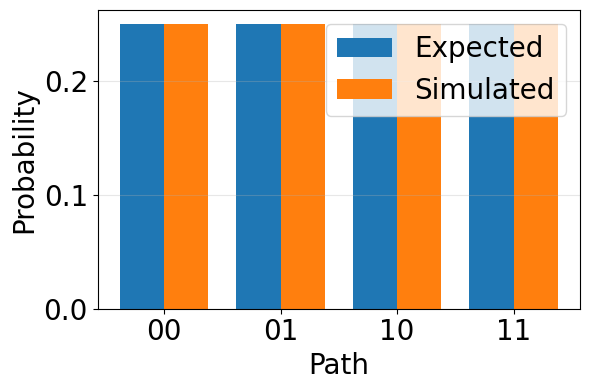

In [5]:
x = np.arange(len(tele_labels))
tele_ref = np.array([tele_target_probs.get(lbl, 0.0) for lbl in tele_labels], dtype=float)
tele_sim = np.array([tele_sim_probs.get(lbl, 0.0) for lbl in tele_labels], dtype=float)

fig, ax = plt.subplots(figsize=(6, 4))
w = 0.38
font_size_tick = 20
font_size_label = 20
ax.tick_params(axis="both", which="major", labelsize=font_size_tick)
ax.bar(x - w / 2, tele_ref, width=w, label="Expected")
ax.bar(x + w / 2, tele_sim, width=w, label="Simulated")
ax.set_xticks(x)
ax.set_xticklabels(tele_labels)
ax.set_xlabel("Path", fontsize=font_size_label)
ax.set_ylabel("Probability", fontsize=font_size_label)
ax.legend(fontsize=20)
ax.grid(axis="y", alpha=0.3)
fig.tight_layout()

tele_out = FIG_DIR / "validation_all_branches_teleportation_probs.pgf"
fig.savefig(tele_out, format="pgf", bbox_inches="tight")
print(f"Saved plot to: {tele_out}")


## 2) Dynamic Teleportation with Final Bob Measurement


In [6]:
def build_dynamic_teleportation_bob_measured_ir(theta, phi):
    ir = CircuitIR(no_qubits=3, no_clbits=3)

    ir.add_operation("u", [0], params=[theta, phi, 0.0])
    ir.add_operation("h", [1])
    ir.add_operation("cx", [1, 2])
    ir.add_operation("cx", [0, 1])
    ir.add_operation("h", [0])
    ir.add_operation("measure", [0], clbits=[0])
    ir.add_operation("measure", [1], clbits=[1])
    ir.add_operation("x", [2], condition={"kind": "clbit_eq", "clbit": 1, "value": 1})
    ir.add_operation("z", [2], condition={"kind": "clbit_eq", "clbit": 0, "value": 1})
    ir.add_operation("measure", [2], clbits=[2])
    return ir


def teleportation_bob_measured_targets(theta, phi):
    alpha = np.cos(theta / 2.0)
    beta = np.exp(1j * phi) * np.sin(theta / 2.0)
    p2_zero = float(np.abs(alpha) ** 2)
    p2_one = float(np.abs(beta) ** 2)

    target_probs = {}
    target_states = {}
    for b0, b1, b2 in product([0, 1], repeat=3):
        p = 0.25 * (p2_one if b2 == 1 else p2_zero)
        label = f"{b0}{b1}{b2}"
        target_probs[label] = float(p)
        target_states[label] = basis_state(3, label)
    return target_probs, target_states


theta_bob = 2.0 * np.arcsin(np.sqrt(0.63))
phi_bob = 0.73
tele_bob_ir = build_dynamic_teleportation_bob_measured_ir(theta_bob, phi_bob)
tele_bob_target_probs, tele_bob_target_states = teleportation_bob_measured_targets(theta_bob, phi_bob)


In [7]:
tele_bob_fidelity, tele_bob_paths = DMRG_dynamic_multi_branches_from_circuit_ir(
    chunk_size=CHUNK_SIZE,
    no_sweeps=NO_SWEEPS,
    bond_dims=bond_dims,
    network_structure=NETWORK_STRUCTURE,
    circuit_ir=tele_bob_ir,
    network_type=NETWORK_TYPE,
    max_branches=None,
    probability_cutoff=0.0,
    max_pruning_error=None,
    return_branches=True,
    return_state=True,
    return_classical_bits=True,
)

tele_bob_sim_probs = {}
tele_bob_state_fids = []
for path in tele_bob_paths:
    label = "".join(str(int(b)) for b in path["classical_bits"])
    p = float(path["probability"])
    tele_bob_sim_probs[label] = tele_bob_sim_probs.get(label, 0.0) + p
    tele_bob_state_fids.append(fidelity(path["state"], tele_bob_target_states[label]))

tele_bob_tvd = tvd(tele_bob_sim_probs, tele_bob_target_probs)
tele_bob_mass_error = abs(1.0 - sum(tele_bob_sim_probs.values()))
tele_bob_labels = sorted(set(tele_bob_target_probs.keys()) | set(tele_bob_sim_probs.keys()))

print(f"Teleportation-with-Bob-measurement final fidelity: {tele_bob_fidelity:.12f}")
print(f"Expected/Recovered paths: {len(tele_bob_target_probs)} / {len(tele_bob_sim_probs)}")
print(f"TVD(sim, analytical): {tele_bob_tvd:.12e}")
print(f"Probability-mass error |1-sum p|: {tele_bob_mass_error:.12e}")
print(f"Path-state fidelity min/mean: {np.min(tele_bob_state_fids):.12f} / {np.mean(tele_bob_state_fids):.12f}")
print("Teleportation-with-Bob-measurement path table:")
print("path  p_analytical   p_simulated   abs_diff")
for label in tele_bob_labels:
    pa = tele_bob_target_probs.get(label, 0.0)
    ps = tele_bob_sim_probs.get(label, 0.0)
    print(f"{label}   {pa: .8f}    {ps: .8f}   {abs(pa-ps): .3e}")


Teleportation-with-Bob-measurement final fidelity: 1.000000000000
Expected/Recovered paths: 8 / 8
TVD(sim, analytical): 3.609546342376e-10
Probability-mass error |1-sum p|: 2.220446049250e-16
Path-state fidelity min/mean: 1.000000000000 / 1.000000000000
Teleportation-with-Bob-measurement path table:
path  p_analytical   p_simulated   abs_diff
000    0.09250000     0.09250000    7.539e-11
001    0.15750000     0.15750000    4.244e-11
010    0.09250000     0.09250000    3.561e-11
011    0.15750000     0.15750000    1.466e-10
100    0.09250000     0.09250000    6.095e-11
101    0.15750000     0.15750000    5.000e-11
110    0.09250000     0.09250000    1.720e-10
111    0.15750000     0.15750000    1.390e-10


Saved plot to: /Users/innocenzo/Desktop/Work/Quantum-Circuit-Simulator-DMRG/notebooks/figures/validation_all_branches_teleportation_bob_measure_probs.pgf


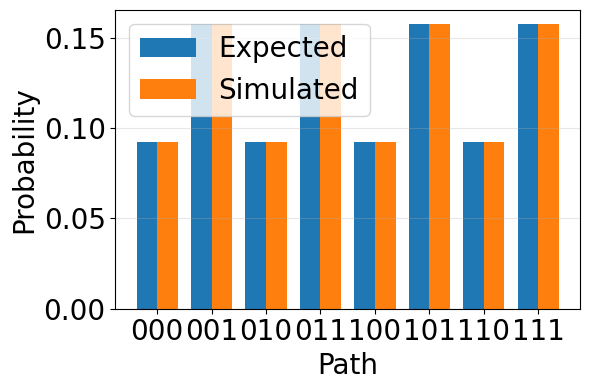

In [8]:
x = np.arange(len(tele_bob_labels))
tele_bob_ref = np.array([tele_bob_target_probs.get(lbl, 0.0) for lbl in tele_bob_labels], dtype=float)
tele_bob_sim = np.array([tele_bob_sim_probs.get(lbl, 0.0) for lbl in tele_bob_labels], dtype=float)

fig, ax = plt.subplots(figsize=(6, 4))
font_size_tick = 20
font_size_label = 20
w = 0.38
ax.bar(x - w / 2, tele_bob_ref, width=w, label="Expected")
ax.bar(x + w / 2, tele_bob_sim, width=w, label="Simulated")
ax.tick_params(axis="both", which="major", labelsize=font_size_tick)
ax.set_xticks(x)
ax.set_xticklabels(tele_bob_labels)
ax.set_xlabel("Path", fontsize=font_size_label)
ax.set_ylabel("Probability", fontsize=font_size_label)
ax.legend(fontsize=20)
ax.grid(axis="y", alpha=0.3)
fig.tight_layout()

tele_bob_out = FIG_DIR / "validation_all_branches_teleportation_bob_measure_probs.pgf"
fig.savefig(tele_bob_out, format="pgf", bbox_inches="tight")
print(f"Saved plot to: {tele_bob_out}")
